# Lab 1: A Little Statistics

    Saraliba Auch
    10/07/2026

### **1. Converting a probability into a 'sigma'. As discussed in class, 'sigma' refers to a probability in physics. Our first task is to figure out how, given a probability, to calculate the assoicated 'sigma' value. The sigma implicitly refers to the standard normal distribution (a Gaussian with mean zero and standard deviation of 1). As we discussed in class, integrals of the standard normal distribution give probabilities.**

**A. Look up the Normal distribution and read about it. A few potential starting points: Math is fun, Wolfram, and a useful z table**

    From Math is Fun:
    -Distribution closely follows a bell curve.
    -Centered on a value; isn't skewed right or left. 
    -Standerdizing a normal distribution produces the z-score. The z-score if found by:
### $z = \frac{x - \mu}{\sigma}$
$\mu$ = mean

$\sigma$ = standard deviation

x = value from normal distribution that is being standardized

**B. As in class, try integrating the standard normal distribution. This can be done either with the erfc(), or calls to specific statistical cumulative probability distributions such as stats.norm.cdf() in scipy. Try several values of sigma, and make sure you are getting values that match the z-table.**

In [34]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats

In [38]:
#This block finds the z-value of 6.75 for a normal distribution centered on 7 and varing sigmas. 

mean = 7 #I choose the mean of the normal distribution to be 7. This value is arbitrary. I decided to create a variable for it so the equations below are easier to read
sigma_value = [1, 2, 3, 4, 5] #These are the different sigma values I will be testing. Ever though the standard deviation has a much broader range, I want to make the z-value closer to zero so that I can use a z-table
x = 6.75 #This is the value that I am standardizing. This is a random value that falls in the normal distributions created. 

#This plugs in each of the sigma values, and finds the cooresponding z-value and probability. 
for sigma in sigma_value:
    z = (x - mean)/sigma #This is the equation above that I got from Math is Fun
    z = np.round(z, decimals = 2) #I will be using the z-table from Wikipedia; which, only shows the probability of z-values up to 2 decimal places. I need to round before calculating the prob so I can accuratly check my results
    prob = stats.norm.cdf(z) #The cdf function finds the probability that a random variable with be less than or equal to z. 
    prob = np.round(prob, decimals = 5) #Wikipedia shows the prob up to 5 decimal places. Rounding is necessary for probability, it just makes checking the answers easier
    print('sigma = ', sigma)
    print('z = ', z)
    print('probability = ', prob)
    print('')

sigma =  1
z =  -0.25
probability =  0.40129

sigma =  2
z =  -0.12
probability =  0.45224

sigma =  3
z =  -0.08
probability =  0.46812

sigma =  4
z =  -0.06
probability =  0.47608

sigma =  5
z =  -0.05
probability =  0.48006



    Here the probabilities of the coorisponding z-values found about. This uses the z-table from Wikipidia. 
    
    z = -0.25
    probability = 0.40129 

    z = -0.12
    probability = 0.45224
    
    z = -0.08
    probability = 0.46812

    z = -0.06
    probability = 0.47608

    z = -0.05
    probability = 0.48006

    These values match the values I calculated. 

**C. Now more often than not, we actually want to do the inverse: for a given probability determine the associated 'sigma' value: stats.norm.ppf() in python. Try several probability values where you know what the answer should be (e.g. Probability associated with 1, 2, 5 sigma), and show that you get the right answer in terms of sigma.**

    stats.norm.ppf() fings the percent point function of a normal distribution. This function does exactly what the question asks for: for a given probability, it will return the associated value that probability corresponds to.
    stats.norm.ppf() has 3 variables associated with it(probability, mean, and sigma), but only one is required (probability). By leaving the other two variable alone, it will defult to a standerdized, normal distribution. This is exactly what I want, since the distribution needs to be standardized in order for me to find the z-value. 

In [43]:
sigma_1 = stats.norm.ppf(0.84134) #should be ~1
print(np.round(sigma_1, decimals =2))

sigma_2 = stats.norm.ppf(0.97725) #should be ~2
print(np.round(sigma_2, decimals =2)) 

sigma_3 = stats.norm.ppf(0.99865) #should be ~3
print(np.round(sigma_3, decimals =2))

sigma_4 = stats.norm.ppf(0.999968) #should be ~4
print(np.round(sigma_4, decimals =2)) 

sigma_5 = stats.norm.ppf(0.99999971) #should be ~5
print(np.round(sigma_5, decimals =2))

1.0
2.0
3.0
4.0
5.0


    The calculated values match documentation. (Again, from Wikipedia, values are rounded to 2 decimal places to match with documentation)

**D. If a minus sign appears, think about it and explain the meaning.**

    That the probability is on the left side of the mean, or in other words, the probability is less than 50% (which has a z-value of 0).

### **2. Now let's explore some other continuous analytic distributions. Following the pattern from your first HW assigment, make both the analytic pdf() and a realization with ~100k samples using a built-in distribution; but this time don't use the Gaussian. Choose one of the following distributions: Rayleigh; Lognormal; Chi-Squared or Gamma; Exponential. You and your partner should choose different distributions.**

**A. Read up on your distribution (wikipedia is your friend).**

    I picked Rayleigh

    From Wikipedia:
    - Continuous probability distribution
    - Distibution only includes random, positive values
    - Skewed right
    - Max is never zero
    - Models the magnitude of vectors with circular symmetry

**B. Make plots (tweaking distribution and plot parameters as needed)**

In [56]:
from scipy.stats import rayleigh
#make a random Rayleigh Distribution

ray_dist = stats.rayleigh.rvs(loc = 2.0, scale = .03, size = 10000000)
#loc is the leftmost value
#scale determines how spread out the distribution is
#both values were arbitrarly chosen

(1.98, 2.13)

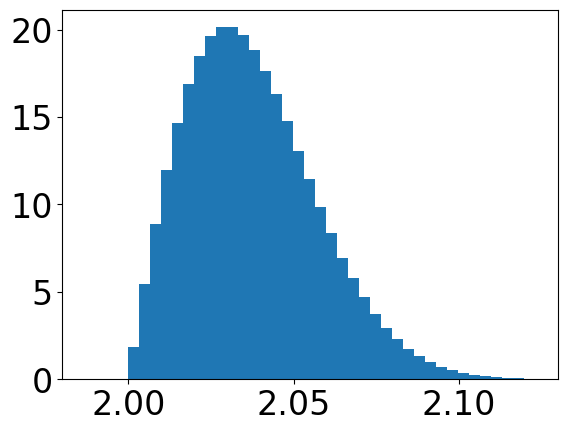

In [111]:
#Plots the Rayleigh Distribution
#Code from homework 1

fig, ax = plt.subplots(1, 1) #Creates the plot
ax.hist(ray_dist,50, density=True) #Plots a hitorgram (data, number of bins, makes it a density histogram)
plt.tick_params(labelsize = 24) #labels the axis
plt.xlim([1.98,2.13]) #sets a limit on the x-axis
# plt.show() #plots the plot

### **3. Imagine that your signal-free data follows the distribution you have chosen; and you have a measurement for which you need to determine the 'sigma'**

**A. Select a value for your hypothetical measurement**

    The value I choose is 2.05

In [60]:
value = 2.05

**B. Clearly state the statistical question you want to ask in words**

    My data follows a Rayleigh distribution. I measured a value of 2.05, what is the probability of measuring a signal of 2.05 or higher, given the distribution?

**C. Convert your word question into a mathematical integral**

    From Wikipedia:

$P(x) = 1 - \int_{0}^{x}{\displaystyle {\frac {x}\sigma ^{2}}}e^{-x^{2}/\left(2\sigma ^{2}\right)}dt$


**D. Use the math to calculate the probability that the background produced the signal (Hint: you will want to use the statistics functions to do the integrals. .cdf() and .ppf() in scipy).**

    stats.rayleigh.cdf calculates the probability of a rayleigh distribution at a certain value.

In [63]:
ray_cdf = 1- stats.rayleigh.cdf(value, loc = 2.0, scale = .03) #cdf find the probabilty of getting the value or lower. I want to find the probability of getting the value or higher, so I do 1 - cdf
print("probability =", ray_cdf)

probability = 0.24935220877729858


    It makes sense for the probability to be less than 50%, as I can see the integral from x to infinity is less than half of the distribution.

**E. Convert your probability into an equivalent 'sigma'**

In [64]:
ray_ppf = stats.norm.ppf(ray_cdf) #The equivalant 'sigma' corresponds to the ppf from a standard, normal distribution. Not a rayleigh distribution. 
print("sigma = ", ray_ppf)

sigma =  -0.6765296659064907


    The sigma of the rayleigh distribution corresponds to the z-value calculated by plugging in the probability from 3(D) into a PPF for a standard, normal distribution. 
    The sigma is -0.68. By double-checking the documentation, I can see a probability of 0.25 corresponds to a simga of -0.67.

### **4. Now explore a little bit. Try various hypothetical measurement values and see how the probabilities and 'sigmas' change. Discuss the patterns that you see.**

In [102]:
ray_cdf = 1- stats.rayleigh.cdf(2.01, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.9459594689067677
sigma =  1.6068783242333449


In [104]:
ray_cdf = 1- stats.rayleigh.cdf(2.02, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.8007374029168077
sigma =  0.8442581004424216


In [129]:
ray_cdf = 1- stats.rayleigh.cdf(2.03, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.6065306597126372
sigma =  0.2702880207387457


In [105]:
ray_cdf = 1- stats.rayleigh.cdf(2.04, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.4111122905071867
sigma =  -0.2246846831924867


In [106]:
ray_cdf = 1- stats.rayleigh.cdf(2.05, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.24935220877729858
sigma =  -0.6765296659064907


In [128]:
ray_cdf = 1- stats.rayleigh.cdf(2.06, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.13533528323661215
sigma =  -1.1015196284987523


In [107]:
ray_cdf = 1- stats.rayleigh.cdf(2.07, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.06572852861653122
sigma =  -1.5083809442394576


In [108]:
ray_cdf = 1- stats.rayleigh.cdf(2.08, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.028565500784550224
sigma =  -1.9023072259179656


In [109]:
ray_cdf = 1- stats.rayleigh.cdf(2.09, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.011108996538242488
sigma =  -2.2866203381786034


In [110]:
ray_cdf = 1- stats.rayleigh.cdf(2.1, loc = 2.0,scale = .03)
print("probability =", ray_cdf)

ray_ppf = stats.norm.ppf(ray_cdf)
print("sigma = ", ray_ppf)

probability = 0.003865920139472734
sigma =  -2.6635609534500286


    - The probability is drops pretty consistanly (probability decreast be ~20 as x increases by 0.01) up until 2.07. Then the probability start decreasing much slower. 
    - Sigma is no longer symmetrical. 0 sigma is roughly as x=0.035,
    - 0 Sigma is no longer the center value.
    - Sigma is roungly linear from 2.03 to 2.10